# 第55篇 | K-Means聚类：无监督学习入门

> 这是「数据分析从入门到精通」系列的第 55 篇。前面学的都是有标签的监督学习，这篇来进入一个全新的世界——无监督学习。K-Means 是最经典的聚类算法，不需要标签，自动发现数据中的群组，客户分群、异常检测都少不了它。

嗨，我是小荷～ 前面学的都是有监督学习（有标签），今天进入**无监督学习**的世界！

---

## 一、什么是有监督 vs 无监督学习？

在机器学习领域，有监督学习（Supervised Learning）和无监督学习（Unsupervised Learning）是两种最核心的学习方式。它们最根本的区别在于训练数据是否带有“标签”（即标准答案）。

1. 有监督学习 (Supervised Learning)： 就像学生做有标准答案的考卷一样，机器通过学习大量带有标签的样本数据，总结出规律并建立预测模型。它利用已知的输入数据和对应的输出结果之间的映射关系来进行学习。
   
3. 无监督学习 (Unsupervised Learning)：就像面对一堆没有标准答案的资料，机器需要自己去探索、分析数据内部的潜在结构、隐藏模式或自然分组。

| 类型 | 输入 | 输出 | 例子 |
|------|------|------|------|
| **有监督** | 数据 + 标签 | 预测标签 | 分类、回归 |
| **无监督** | 只有数据 | 发现结构 | 聚类、降维 |

**聚类的应用场景**：
- 客户分群（精准营销）
- 文档分类（主题发现）
- 图像分割
- 异常检测
- 基因表达分析

下面我们做一个K-Means 聚类算法的入门演示：
1. 生成测试数据：使用 make_blobs 函数生成 300 个二维样本点，这些点被人为设定为 4 个自然聚集的中心（即真实类别数为 4）
2. 原始数据的可视化：绘制两张子图来展示数据的分布状态，左图是没标签的原始数据（灰色）；右图是真实的簇分布（彩色）2

K-Means聚类入门
数据形状: (300, 2)
真实类别数: 4


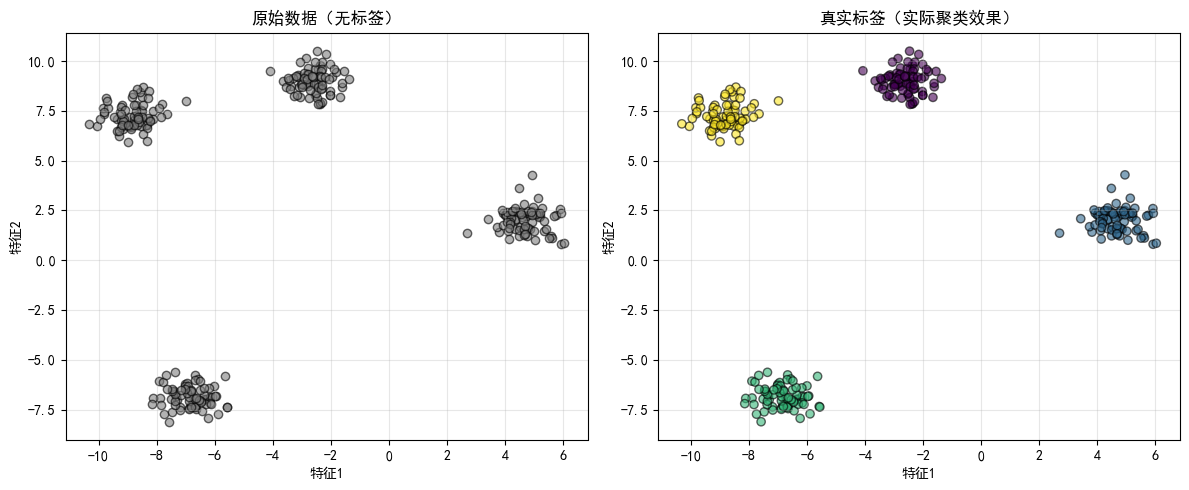

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans'] # 设置支持中文的字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常问题

# 打印标题
print("K-Means聚类入门")

# 生成聚类数据
np.random.seed(42) # 固定随机种子，保证每次运行数据一样
X, y_true = make_blobs(n_samples=300,  # 生成300个数据点
                       centers=4,  # 分为4个真实簇
                       cluster_std=0.60,  # 簇内数据的标准差（越小越密集）
                       random_state=42)

print(f"数据形状: {X.shape}") # 输出 (300,2)：300行2列（2个特征）
print(f"真实类别数: {len(np.unique(y_true))}")  # 真实簇数量：4

# 可视化原始数据 
plt.figure(figsize=(12, 5))  # 创建画布，宽12，高5

# 左图：无标签的原始数据
plt.subplot(1, 2, 1)  # 1行2列的第1个子图
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, edgecolors='k') # 画散点图
plt.title('原始数据（无标签）')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.grid(True, alpha=0.3)   # 显示网格

# 右图：带真实簇标签的数据
plt.subplot(1, 2, 2) # 1行2列的第2个子图
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, edgecolors='k')  # c=y_true，按真实类别上色
plt.title('真实标签（实际聚类效果）')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 二、K-Means算法原理


我们可以把 K-Means 算法想象成一个“物以类聚，人以群分”的分配和调整游戏。它的核心目的是：把一堆杂乱无章的数据，自动分成 k 个堆（簇/类别），让同一堆里的东西尽可能相似，不同堆的东西尽可能分开。


我们可以把 **K-Means 算法**想象成一个“物以类聚，人以群分”的分配和调整游戏。

它的核心目的是：**把一堆杂乱无章的数据，自动分成 $K$ 个堆（簇/类别），让同一堆里的东西尽可能相似，不同堆的东西尽可能分开。**


### 一个通俗的比喻：给新生分班

假设开学了，操场上站着 100 个完全不认识的新生。老师想把他们分成 **3个班（这就是 $K=3$）**，但老师没有任何他们的资料，只知道他们的身高和体重。怎么办呢？

K-Means 算法是这样做的：

#### 第一步：随便抓几个人当班长（初始化）

老师在操场上**随机**指了 3 个学生，让他们先当这 3 个班的临时“班长”（也就是 3 个聚类中心）。

#### 第二步：看谁离我近就进谁的班（分配）

剩下的 97 个学生开始看这 3 个班长。每个学生都会对比自己和 3 个班长的身高体重，**谁和自己最接近（距离最近），自己就站到哪个班长的队伍后面**。
一轮下来，100 个学生就被临时分成了 3 个队伍。

#### 第三步：选出新班长（更新中心）

现在的 3 个队伍是随便凑出来的，不一定最合理。
于是，每个队伍的成员站在一起，**算出他们这个队伍的“平均身高”和“平均体重”**。这个“平均人”的位置就是这个班级真正的内容核心。
老师宣布：刚才那 3 个临时班长退位，由每个班的“平均人”坐标作为**新班长**（真正的班长可能是一个虚拟的点）。

#### 第四步：重新选班（循环迭代）

因为班长的位置变了，学生们重新看一遍：我现在离哪个新班长最近？
有些学生可能会发现，调整后自己其实离隔壁班的新班长更近了，于是他就会“叛逃”到隔壁班。

#### 第五步：大功告成（收敛）

重复“第三步（算平均值选新班长）”和“第四步（学生重新选班）”。
直到**连续几次，大家都发现自己不需要再换班了，班长的位置也彻底固定了**。游戏结束，分班完成！

---

### K-Means 的标准步骤

1. **选定 $K$ 值**：决定要分出多少个类别。
2. **随机选点**：在数据中随机挑 $K$ 个点作为初始的“聚类中心”。
3. **计算距离并归类**：计算每个数据点到这 $K$ 个中心的距离，把每个点归到离它最近的那个中心。
4. **重新计算中心**：算一下每个类别里所有点的平均值（均值 Mean），把这个平均值的位置作为新的聚类中心。
5. **重复与收敛**：重复第 3 和第 4 步，直到中心点不再发生变化，算法结束。


### 这个算法的优缺点

* **优点**：
* **非常快**：逻辑简单，计算速度杠杠的，适合处理大数据。
* **好理解**：纯粹靠距离说话，简单粗暴。


* **缺点**：
* **$K$ 值要盲猜**：你必须提前告诉它分几类（$K$ 是多少）。如果连你自己都不知道该分几类，就会很纠结。
* **怕脏数据（异常值）**：如果班里混进了一个身高 2 米 5 的巨人，在算平均身高（第三步）时，他一个人就会把整个班的平均线大幅拉偏。
* **结果受运气影响**：如果一开始随机选的“临时班长”位置太奇葩，最后分出来的结果可能不是最优的。

下面我们用代码来给K-Means 算法原理的核心迭代步骤做个“慢动作回放”：
1. 模拟算法的核心机制：step1,随机选质心; step2,按距离分配样本; step3,重新计算质心
2. 绘制包含 3 个子图的图表:
   - 左图：展示灰色散点（原始数据）和红色叉号（初始质心）
   - 中图：展示数据点根据距离被染上不同颜色（完成第一次选边站），但质心仍在原位
   - 右图：展示红色叉号移动到了新计算出的平均位置（质心发生偏移）


K-Means算法演示:
初始质心:
[[ 4.28625998  2.48293094]
 [-6.80744981 -6.57144629]
 [ 4.80847396  1.59954997]]

样本分配结果: [148 115  37]

更新后的质心:
[[-2.18579355  6.95479286]
 [-7.67153738 -2.04493907]
 [ 5.01122722  1.64713126]]


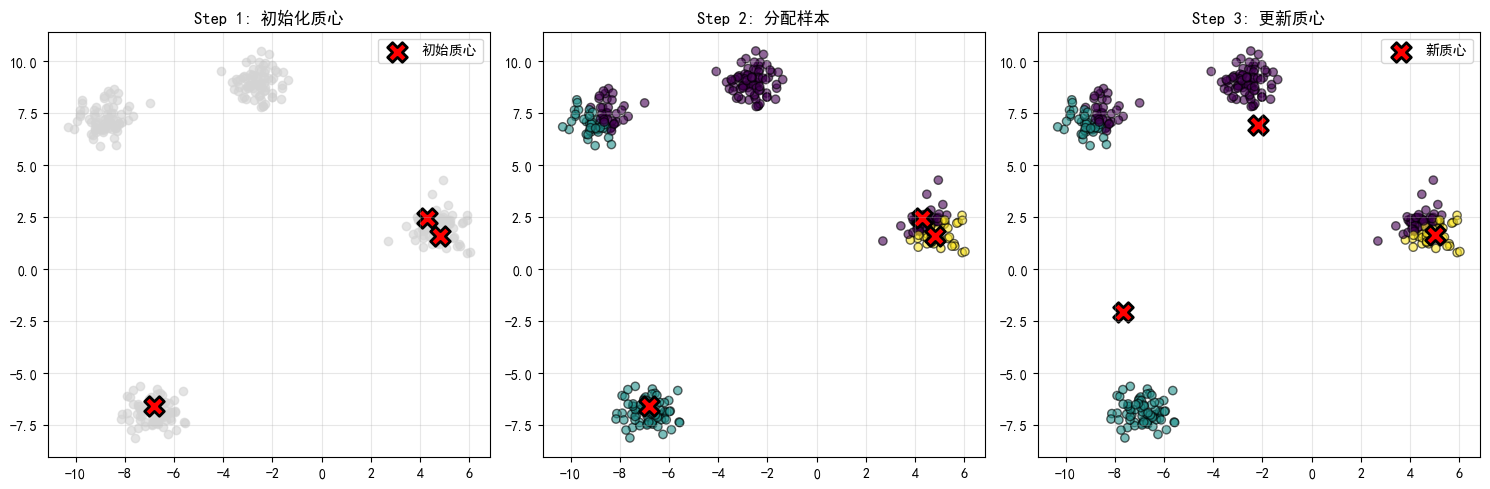

In [4]:
print("\nK-Means算法演示:")
print("=" * 60)

# 手动演示K-Means的一次迭代
K = 3   # 设定聚类成 3 个簇

# step1: 随机初始化质心
np.random.seed(42)
# 从数据 X 中随机选 K 个样本作为初始质心
initial_centroids = X[np.random.choice(X.shape[0], K, replace=False)] 

print(f"初始质心:\n{initial_centroids}")

# step2: 分配样本到最近的质心
# 定义函数：计算每个点到质心的距离，返回所属簇标签
def assign_clusters(X, centroids):
    # 计算所有点到所有质心的欧氏距离
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    # 返回距离最小的质心索引（标签）
    return np.argmin(distances, axis=0)

# 执行分配，得到每个样本的标签
labels = assign_clusters(X, initial_centroids)
print(f"\n样本分配结果: {np.bincount(labels)}")

# step3: 更新质心
# 对每个簇，求所有点的平均值作为新质心
new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
print(f"\n更新后的质心:\n{new_centroids}")

# 可视化 K-Means 一次迭代过程
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 1行3张图

# ---------- 第一张图：Step1 初始化质心 ----------
axes[0].scatter(X[:, 0], X[:, 1], c='lightgray', alpha=0.6)  # 画所有数据点
axes[0].scatter(initial_centroids[:, 0], initial_centroids[:, 1], 
               c='red', s=200, marker='X', edgecolors='k', linewidths=2, label='初始质心')
axes[0].set_title('Step 1: 初始化质心')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------- 第二张图：Step2 分配样本 ----------
axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].scatter(initial_centroids[:, 0], initial_centroids[:, 1], 
               c='red', s=200, marker='X', edgecolors='k', linewidths=2)
axes[1].set_title('Step 2: 分配样本')
axes[1].grid(True, alpha=0.3)

# ---------- 第三张图：Step3 更新质心 ----------
axes[2].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
axes[2].scatter(new_centroids[:, 0], new_centroids[:, 1], 
               c='red', s=200, marker='X', edgecolors='k', linewidths=2, label='新质心')
axes[2].set_title('Step 3: 更新质心')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 三、Scikit-learn实现K-Means

K-Means 是最经典的聚类算法，来上手试试：



K-Means聚类结果:
----------------------------------------
质心坐标:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]

每个簇的样本数: [75 75 75 75]
迭代次数: 2
惯性(Inertia): 203.89


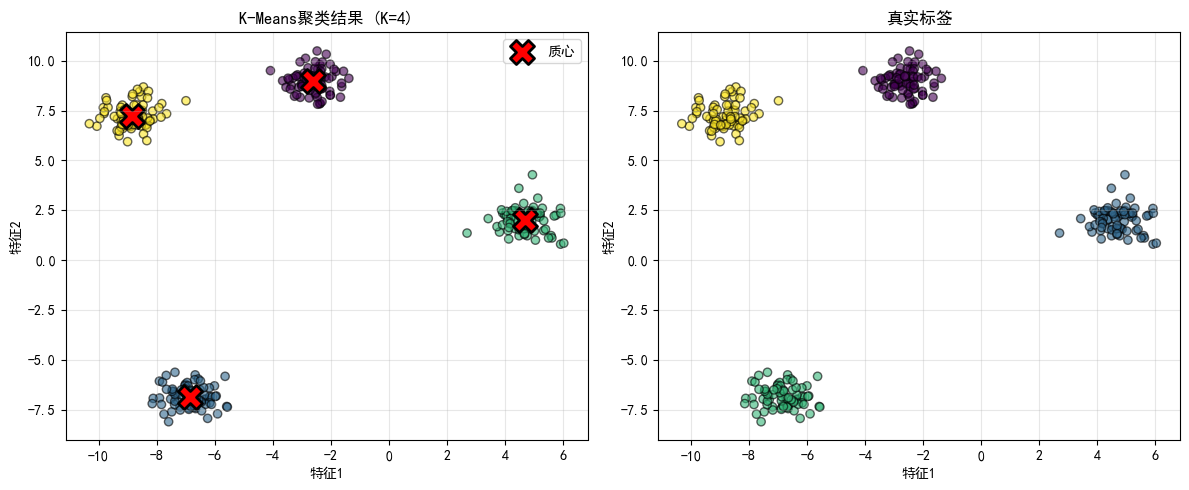


聚类效果评估:
----------------------------------------
轮廓系数: 0.8756
Calinski-Harabasz指数: 9411.51


In [5]:
# 使用sklearn的KMeans
# 创建 K-Means 模型：聚成 4 类，固定随机种子，自动尝试 10 次初始质心选最优
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# 用数据 X 训练模型（执行聚类）
kmeans.fit(X)

print(f"\nK-Means聚类结果:")
print(f"质心坐标:\n{kmeans.cluster_centers_}")
print(f"\n每个簇的样本数: {np.bincount(kmeans.labels_)}")
print(f"迭代次数: {kmeans.n_iter_}")
print(f"惯性(Inertia): {kmeans.inertia_:.2f}")

# 可视化聚类结果
plt.figure(figsize=(12, 5))

# 左图：展示 K-Means 算出的聚类结果
plt.subplot(1, 2, 1) # 1行2列，第1个子图
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6, edgecolors='k') # 画数据点，颜色按聚类标签区分
# 画出红色的质心，标记为 X
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', s=300, marker='X', edgecolors='k', linewidths=2, label='质心')
plt.title('K-Means聚类结果 (K=4)')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.legend()
plt.grid(True, alpha=0.3)

# 右图：展示真实的标签（用于对比）
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, edgecolors='k')
plt.title('真实标签')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n聚类效果评估:")
# 轮廓系数：[-1,1]，越接近1表示簇内越紧密、簇间越分离，效果越好
print(f"轮廓系数: {silhouette_score(X, kmeans.labels_):.4f}")
# Calinski-Harabasz指数：数值越大，聚类效果越好
print(f"Calinski-Harabasz指数: {calinski_harabasz_score(X, kmeans.labels_):.2f}")


这段代码做了 4 件事：
1. 用 sklearn 训练 K-Means（K=4）
2. 输出质心、样本数、迭代次数、惯性
3. 画图对比：聚类结果 vs 真实标签
4. 用轮廓系数、CH 指数评估聚类好不好

无监督聚类的两个经典内部评估指标：

- 轮廓系数 (Silhouette Score)：取值在 -1 到 1 之间。综合衡量簇内的紧密度和簇间的分离度，得分越接近 1 说明聚类效果越佳。
- Calinski-Harabasz 指数：通过计算簇间方差与簇内方差的比值来评估。该数值越大，说明簇间差异明显且簇内高度集中，代表聚类效果越好。

---

## 四、如何选择K值？

选择 $K$ 值，其实就像是你去开一家连锁便利店，“到底该开几家分店”的博弈过程：

* 店开得**太少**（$K$ 太小）：客户要走很久才能到店里，体验很差（数据点离中心太远，分类太粗糙）。
* 店开得**太多**（$K$ 太大）：虽然每个人出门就是便利店，但成本起飞，甚至可能变成“一人一家店”，失去了开店的意义（分类过细，失去了聚类的价值，甚至导致过拟合）。

在实际操作中，数据科学家通常用以下两个最通俗、最常用的方法来“猜”出最合适的 $K$ 值：

### 1. 手肘法（Elbow Method）—— 找“性价比最高”的拐点

手肘法是目前最常用的方法。它的核心思想是看“所有点到它们各自中心的距离之和”（在数学上叫 **SSE，残差平方和**）。

* **规律**：分店（$K$ 值）开得越多，大家到店的距离（SSE）绝对是越短的。如果 $K$ 等于数据点的总数，那距离就是 0。
* **做法**：我们尝试不同的 $K$ 值（比如 $K=1, 2, 3 \dots 10$），然后画一张折线图。横坐标是 $K$ 的数量，纵坐标是距离之和。
* **怎么选**：你会发现，一开始 $K$ 增加时，距离之和会**急速下降**（说明多开店效果显著）；但是到了某一个点之后，再增加 $K$，距离下降得就**非常慢**了（说明再多开店就是浪费了）。

> 💡 **通俗结论**：这张图看起来就像人的**一条手臂**。那个下降速度突然变缓的转折点，就像是**“手肘”**。**“手肘”对应的 $K$ 值，就是性价比最高的黄金选择。**


### 2. 轮廓系数法（Silhouette Method）—— 看看成员们“满不满意”

手肘法只考虑了“自己人和中心离得近不近”，而轮廓系数法还考虑了“和隔壁班分得开不开”。

它会给每个数据点打一个“满意度得分”（范围在 -1 到 1 之间）：

* **得分接近 1**：说明自己离本班中心很近，离隔壁班都很远。大家很满意，分类很成功！
* **得分接近 0**：说明自己刚好站在两个班的国境线上，去哪都差不多。
* **得分接近 -1**：说明自己其实离隔壁班更近，被硬生生分错班了。

> 💡 **通俗结论**：我们去计算不同 $K$ 值下，所有点的**平均满意度得分**。**哪一个 $K$ 值让大家的平均得分最高，我们就选哪个 $K$。**


### 3. 业务导向法 —— 彻底抛弃数学，按需求来

有时候，数学公式算出来的最优 $K$ 值，在现实中可能毫无用处。**业务需求才是真正的指挥棒。**

* **服装厂做衣服**：你想把客户群聚类以设计尺码。数学可能告诉你 $K=7$ 最完美，但工厂老板会开除你，因为生产 7 个尺码的成本太高了。最终只能根据预算，强行设定 $K=3$（S、M、L 码）或者 $K=5$。
* **用户画像精准营销**：市场部只有 4 笔预算，只能针对 4 种不同的客户群体设计 4 套营销方案。那不用想了，$K$ 只能等于 4。

### 📝 总结：选 $K$ 值的标准工作流

在实际工作中，我们通常是“先看业务，再看手肘”：

1. 先根据**业务经验**宏观锁定一个大概的范围（比如分 3~6 类）。
2. 在这个范围内跑一下**手肘法**和**轮廓系数**，看数学上哪个值表现最好。
3. 结合两者的结果，定下最终的 $K$ 值。


下面我们通过肘部法则（Elbow Method）和轮廓系数（Silhouette Score）这两种经典方法，来确定 K-Means 聚类算法的最佳簇数（K值）：
1. 遍历计算评估指标
   - 设定范围：将候选的 K 值设定为 2 到 10。
   - 循环训练：对每一个 K 值初始化并训练一个 K-Means 模型。
   - 提取数据：在每次训练中，分别记录两个关键指标inertia_（惯性）和silhouette_score（轮廓系数）。
3. 绘制左右两张子图，直观展示不同 K 值下的表现
   - 左图（肘部法则）：以折线图展示惯性随 K 值增加而下降的趋势，用红色虚线标记拐点。
   - 右图（轮廓系数法）：以折线图展示轮廓系数的变化趋势，并用红线标出取得最高分的 K 值。

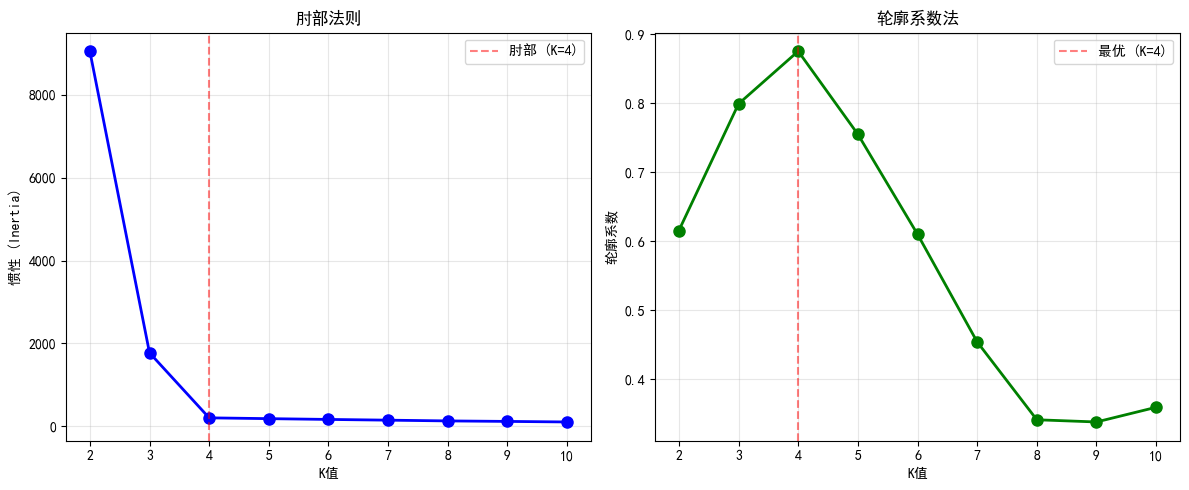


K值选择方法:
----------------------------------------
肘部法则: 找惯性下降变缓的点（像手肘）
轮廓系数: 取值范围[-1, 1]，越接近1越好

当前数据:
  肘部法则建议: K=4
  轮廓系数建议: K=4 (得分: 0.8756)


In [6]:
# ===================== 肘部法则 + 轮廓系数 选择最优K值 =====================
# 用来存储不同K下的惯性值（肘部法则用）
inertias = []
# 用来存储不同K下的轮廓系数（评估聚类效果用）
silhouette_scores = []
# 测试 K 从 2 到 10 的所有情况
K_range = range(2, 11)

# 循环遍历每一个 K 值
for k in K_range:
    # 创建 KMeans 模型，当前聚成 k 个簇
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    # 训练模型
    kmeans_temp.fit(X)
    # 把当前 k 的惯性存入列表
    inertias.append(kmeans_temp.inertia_)
    # 把当前 k 的轮廓系数存入列表
    silhouette_scores.append(silhouette_score(X, kmeans_temp.labels_))

# 创建画布，大小 12x5，用来放两张图
plt.figure(figsize=(12, 5))

# ---------- 左图：绘制 肘部法则 曲线 ----------
plt.subplot(1, 2, 1)  # 1行2列，第1个子图
# 画 K值 和 惯性 的关系曲线
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K值')          # x轴名称
plt.ylabel('惯性 (Inertia)')# y轴名称
plt.title('肘部法则')       # 标题
plt.grid(True, alpha=0.3)   # 显示网格
# 用红色虚线标记出 手肘点 K=4（我们观察出来的最佳点）
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='肘部 (K=4)')
plt.legend()  # 显示图例

# ---------- 右图：绘制 轮廓系数 曲线 ----------
plt.subplot(1, 2, 2)  # 1行2列，第2个子图
# 画 K值 和 轮廓系数 的关系曲线
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('K值')            # x轴名称
plt.ylabel('轮廓系数')      # y轴名称
plt.title('轮廓系数法')     # 标题
plt.grid(True, alpha=0.3)   # 显示网格
# 找到轮廓系数最大的 K 值
best_k = list(K_range)[np.argmax(silhouette_scores)]
# 用红色虚线标记最优 K 值
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'最优 (K={best_k})')
plt.legend()  # 显示图例

# 自动调整子图间距，让图更美观
plt.tight_layout()
# 显示两张对比图
plt.show()

# ===================== 输出方法说明与最终建议 =====================
print("\nK值选择方法:")
print("-" * 40)
print("肘部法则: 找惯性下降变缓的点（像手肘）")
print("轮廓系数: 取值范围[-1, 1]，越接近1越好")
print(f"\n当前数据:")
print(f"  肘部法则建议: K=4")
print(f"  轮廓系数建议: K={best_k} (得分: {max(silhouette_scores):.4f})")

轮廓系数详解

之前我们计算的“平均轮廓系数”只是给整个聚类结果打了一个综合平均分，现在我们把成绩单拆解开，来看一下每一个簇（组）内部的表现。

下面的代码我们做3件事：
1. 获取每个样本的独立得分：使用 silhouette_samples 函数，计算数据集中每一个样本点自己的轮廓系数
2. 绘制各簇的轮廓系数分布（水平柱状图）
3. 引入全局基准线进行对比：红色的垂直虚线，代表整个数据集的平均轮廓系数

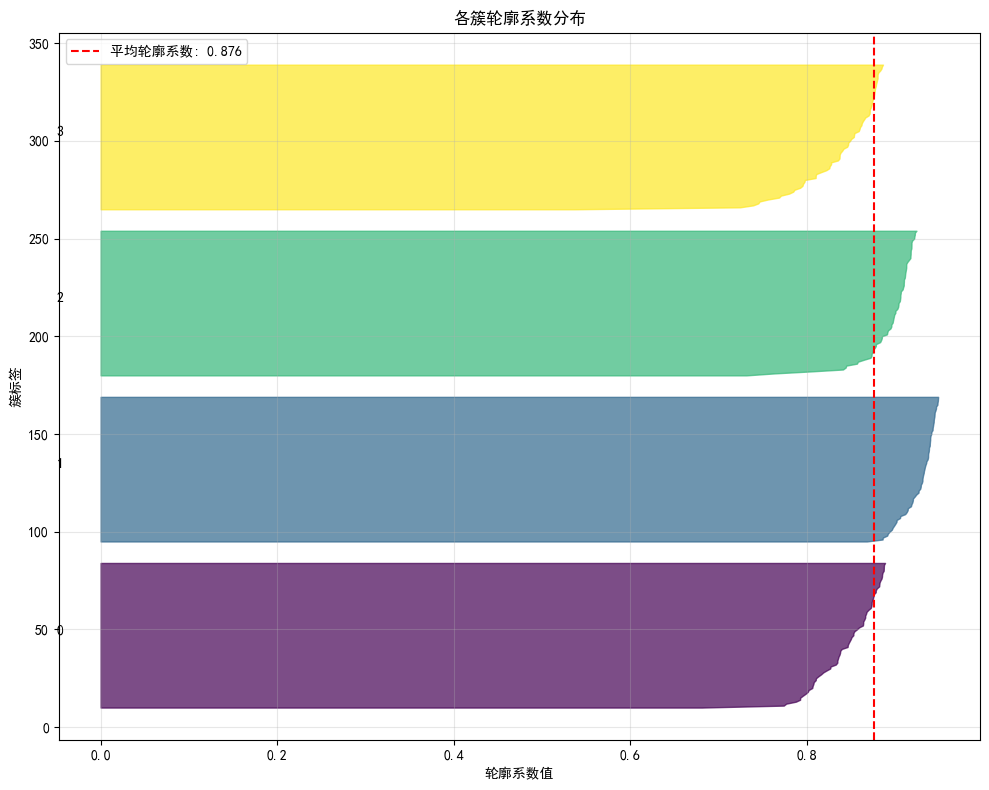

In [8]:
# 导入计算每个样本轮廓系数的工具
from sklearn.metrics import silhouette_samples

# 计算数据 X 中，每一个样本 自己的轮廓系数
sample_silhouette_values = silhouette_samples(X, kmeans.labels_)

# 创建一张大图，用来画轮廓系数分布图
fig, ax = plt.subplots(figsize=(10, 8))

# 生成 4 种颜色（因为聚成 4 类），给每个簇分配不同颜色
colors = plt.cm.viridis(np.linspace(0, 1, 4))

# 设置画图的起始纵坐标位置
y_lower = 10

# 循环 4 个簇，分别画每个簇的轮廓系数
for i in range(4):
    # 取出第 i 个簇里所有样本的轮廓系数
    ith_cluster_silhouette_values = sample_silhouette_values[kmeans.labels_ == i]
    
    # 把这个簇的轮廓系数从小到大排序（画图更美观）
    ith_cluster_silhouette_values.sort()
    
    # 统计这个簇有多少个样本
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    
    # 计算这个簇在图上的结束纵坐标
    y_upper = y_lower + size_cluster_i

    # 填充当前簇的轮廓系数区域图
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),  # Y轴范围
        0, ith_cluster_silhouette_values,  # X轴：轮廓系数值
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7  # 颜色
    )
    
    # 在图左侧标记簇编号 0、1、2、3
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    # 更新下一个簇的起始Y坐标，留出空隙
    y_lower = y_upper + 10

# 画红色虚线：表示整体平均轮廓系数
ax.axvline(
    x=silhouette_score(X, kmeans.labels_), 
    color="red", linestyle="--", 
    label=f'平均轮廓系数: {silhouette_score(X, kmeans.labels_):.3f}'
)

# 设置坐标轴标题
ax.set_xlabel("轮廓系数值")
ax.set_ylabel("簇标签")
ax.set_title("各簇轮廓系数分布")
ax.legend()        # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格

plt.tight_layout()  # 自动调整布局
plt.show()          # 显示图像

从图中可以看到：
- 平均轮廓系数高：图中红色虚线标注的平均轮廓系数为 0.876。这是一个非常高的数值（接近 1），说明整体的聚类结构非常清晰，簇与簇之间分得很开，且簇内的点很紧凑。
- 无负值区域：所有的色块都位于 X 轴的正半轴（大于 0），这意味着没有明显的错误分类样本（即没有被分到“离家更远”的错误簇里的点）。

可以说明整体表现非常优秀了，这意味着 K 值（这里是 4）是非常合适的，无需再调整。

**附：轮廓系数解读:**

• > 0.7: 聚类效果很好
• 0.5-0.7: 聚类效果合理
• 0.25-0.5: 聚类效果一般
• < 0.25: 聚类效果差，可能需要重新考虑

---

## 五、K-Means的优缺点与注意事项

**优点：**
1. 简单快速，时间复杂度O(n*k*i)，n样本数，k簇数，i迭代数
2. 可扩展性好，适合大数据集
3. 结果可解释性强
4. 收敛速度快

**缺点：**
1. 需要预先指定K值
2. 对初始质心敏感（可能收敛到局部最优）
3. 对异常值敏感
4. 假设簇是凸形（球形），对非凸形状效果差
5. 对特征尺度敏感，需要标准化

**使用注意事项：**
1. 必须标准化特征！
2. 使用n_init多次随机初始化
3. 先用肘部法则/轮廓系数确定K
4. 检查异常值

下面我们生成两个弯月亮形状的数据（不是圆形 / 球形），用 K-Means 聚类看看结果怎么样。

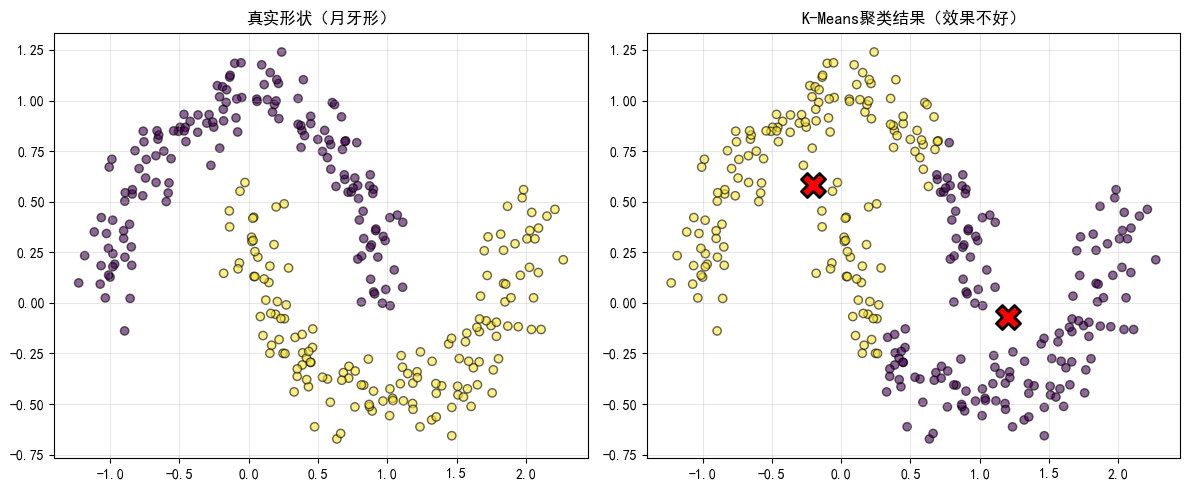

In [10]:
# 演示 K-Means 对非凸形状（月牙形）数据的缺陷
# 生成月牙形状的测试数据（非球形、非凸数据）
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

# 创建 K-Means 模型，聚成 2 类
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
# 在月牙数据上训练 K-Means
kmeans_moons.fit(X_moons)

# 创建画布，准备画两张对比图
plt.figure(figsize=(12, 5))

# 左图：展示真实的月牙形数据分布
plt.subplot(1, 2, 1)  # 1行2列，第1个子图
# 绘制散点图，颜色按照真实标签区分
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.6, edgecolors='k')
plt.title('真实形状（月牙形）')  # 标题
plt.grid(True, alpha=0.3)        # 显示网格

# 右图：展示 K-Means 的聚类结果
plt.subplot(1, 2, 2)  # 1行2列，第2个子图
# 绘制散点图，颜色按照 K-Means 预测的标签区分
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons.labels_, cmap='viridis', alpha=0.6, edgecolors='k')
# 绘制红色大叉，表示 K-Means 找到的质心
plt.scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], 
           c='red', s=300, marker='X', edgecolors='k', linewidths=2)
plt.title('K-Means聚类结果（效果不好）')  # 标题
plt.grid(True, alpha=0.3)                  # 显示网格

# 自动调整子图间距，让图表更美观
plt.tight_layout()
# 显示图像
plt.show()

上图说明：K-Means假设簇是球形，对月牙形数据效果不好

解决方案：使用DBSCAN或谱聚类等算法


---

## 六、K-Means参数详解

n_clusters (K): 簇的数量
  - 最重要参数，用肘部法则或轮廓系数确定

init: 初始化方法
  - 'k-means++': 默认，智能选择初始质心
  - 'random': 随机选择
  - 也可以传入自定义质心

n_init: 运行次数
  - 默认10，用不同初始化跑多次，选最好的
  - 增加可减少陷入局部最优的风险

max_iter: 最大迭代次数
  - 默认300
  - 算法收敛或达到最大迭代时停止

tol: 收敛阈值
  - 默认1e-4
  - 质心移动小于此值认为收敛

algorithm: 算法实现
  - 'lloyd': 经典EM算法
  - 'elkan': 使用三角不等式加速，适合稠密数据

下面我们用代码展示n_init（初始化次数）和 n_clusters（簇数量）对最终效果的影响。

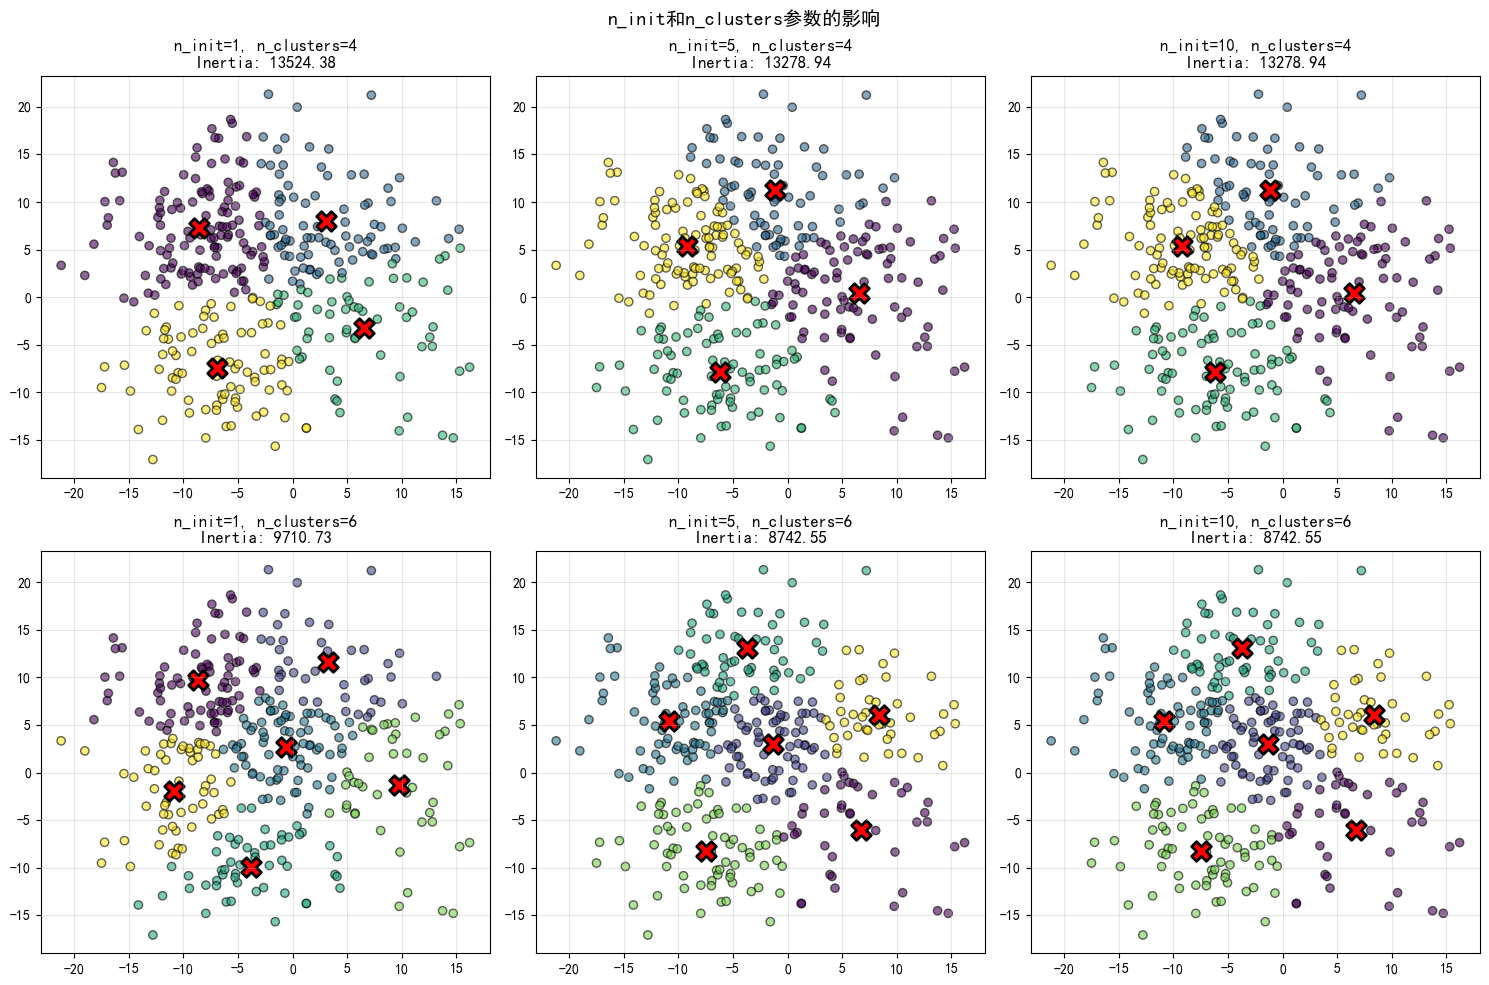

In [21]:
# 对比不同初始化次数 n_init 对 K-Means 结果的影响

# 1. 生成重叠极其严重、形态更散的数据（标准差从 1.8 提高到 3.5）
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=5, random_state=42)

# 2. 强行注入 50 个全操场乱跑的“极端噪点/异常值”
np.random.seed(99)
noise = np.random.uniform(low=-15, high=15, size=(50, 2))
X = np.vstack([X, noise])  # 把噪点合并到原始数据中

# 创建 2行3列 的子图布局，整体画布大小 15x10
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 循环测试 3 种 n_init 值：1、5、10，idx 是索引，n_init 是当前值
for idx, n_init in enumerate([1, 5, 10]):
    # ==================== 第一次运行：固定随机种子 42 ====================
    # 创建 K-Means 模型，聚4类，初始化次数为 n_init
    km1 = KMeans(n_clusters=4, n_init=n_init, random_state=42)
    # 训练模型
    km1.fit(X)
    
    # 选择第一行第 idx 列的子图画图
    ax = axes[0, idx]
    # 绘制聚类后的散点图，颜色按聚类标签区分
    ax.scatter(X[:, 0], X[:, 1], c=km1.labels_, cmap='viridis', alpha=0.6, edgecolors='k')
    # 绘制红色大叉，表示聚类质心
    ax.scatter(km1.cluster_centers_[:, 0], km1.cluster_centers_[:, 1], 
              c='red', s=200, marker='X', edgecolors='k', linewidths=2)
    # 设置标题：显示 n_init 和惯性值（越小越好）
    ax.set_title(f'n_init={n_init}, n_clusters=4\nInertia: {km1.inertia_:.2f}')
    # 显示网格
    ax.grid(True, alpha=0.3)
    
    # ==================== 第二次运行：更换n_clusters ====================
    # 创建模型，n_init 不变，n_clusters = 6
    km2 = KMeans(n_clusters=6, n_init=n_init, random_state=42)
    km2.fit(X)
    
    # 选择第二行第 idx 列的子图画图
    ax = axes[1, idx]
    ax.scatter(X[:, 0], X[:, 1], c=km2.labels_, cmap='viridis', alpha=0.6, edgecolors='k')
    ax.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], 
              c='red', s=200, marker='X', edgecolors='k', linewidths=2)
    ax.set_title(f'n_init={n_init}, n_clusters=6\nInertia: {km2.inertia_:.2f}')
    ax.grid(True, alpha=0.3)

# 设置整个图表的总标题
plt.suptitle('n_init和n_clusters参数的影响', fontsize=14, fontweight='bold')
# 自动调整子图间距，防止重叠
plt.tight_layout()
# 显示图表
plt.show()

1. 横向对比：n_init 的作用：观察每一行，随着 n_init 从 1 增加到 5 再到 10，Inertia（惯性/误差平方和）通常会降低或趋于稳定。
2. 纵向对比：n_clusters (K值) 的影响：
    - 第一行 (K=4)：数据被分成 4 组。可以看到 Inertia 较高（约 13000+），说明有些本应分开的点被强行归到了一起，或者分组不够细致。
    - 第二行 (K=6)：数据被分成 6 组。Inertia 显著下降（降至 8700-9700 左右）。

图中右侧两列（n_init=5 和 10）的结果明显比左侧（n_init=1）更可靠。这告诉我们在使用 K-Means 时，不要使用默认的 n_init=1（旧版本默认值），至少设置为 10 次以上，以避免因运气不好导致的糟糕聚类结果。

虽然 K=6 的 Inertia 更低，但这并不代表 K=6 一定比 K=4 好（可能会过拟合）。实际应用中需结合业务需求或轮廓系数来最终决定 K 值，但无论选哪个 K，都要保证 n_init 足够大。

---

## 七、综合实战：客户分群

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [29]:
print("综合实战：电商客户分群")

# 模拟客户数据
np.random.seed(42)
n_customers = 500

# ========== 改造：构造 5 类客户数据（适配 K=5 聚类） ==========
# 均分5组，每组100人
group_size = n_customers // 5

# 1. 组1：高收入 + 高消费
g1_income = np.random.normal(90000, 8000, group_size)
g1_spend = np.random.uniform(70, 100, group_size)

# 2. 组2：高收入 + 低消费
g2_income = np.random.normal(85000, 8000, group_size)
g2_spend = np.random.uniform(10, 30, group_size)

# 3. 组3：中等收入 + 中等消费
g3_income = np.random.normal(50000, 10000, group_size)
g3_spend = np.random.uniform(40, 60, group_size)

# 4. 组4：低收入 + 高消费（月光型）
g4_income = np.random.normal(25000, 6000, group_size)
g4_spend = np.random.uniform(65, 95, group_size)

# 5. 组5：低收入 + 低消费
g5_income = np.random.normal(20000, 6000, group_size)
g5_spend = np.random.uniform(5, 25, group_size)

# 拼接所有数据
annual_income = np.concatenate([g1_income, g2_income, g3_income, g4_income, g5_income])
spending_score = np.concatenate([g1_spend, g2_spend, g3_spend, g4_spend, g5_spend])
age = np.random.normal(40, 12, n_customers)
purchase_frequency = np.random.poisson(10, n_customers)

# 构建DataFrame
customer_data = pd.DataFrame({
    'annual_income': annual_income,
    'spending_score': spending_score,
    'age': age,
    'purchase_frequency': purchase_frequency
})

# 限制数值范围，保证业务合理
customer_data['annual_income'] = np.clip(customer_data['annual_income'], 15000, 150000)
customer_data['age'] = np.clip(customer_data['age'], 18, 70)

print("客户数据预览:")
print(customer_data.head(10))
print(f"\n数据统计:")
print(customer_data.describe())


综合实战：电商客户分群
客户数据预览:
   annual_income  spending_score        age  purchase_frequency
0   93973.713224       82.522330  34.126727                  10
1   88893.885591       76.663234  52.529931                  11
2   95181.508305       73.595961  48.182698                   4
3  102184.238851       80.128455  62.160488                   6
4   88126.773002       98.287291  47.007138                  10
5   88126.904344       79.696088  35.688495                   2
6  102633.702524       85.563719  47.087858                  12
7   96139.477833       91.090569  53.304443                   4
8   86244.204913       80.908888  49.845786                  17
9   94340.480349       99.153462  46.087288                   8

数据统计:
       annual_income  spending_score         age  purchase_frequency
count     500.000000      500.000000  500.000000          500.000000
mean    54197.101717       49.376186   41.039683           10.016000
std     29849.826340       29.319188   11.570879            3.

数据看完了，选取收入和消费评分两个维度来做聚类：


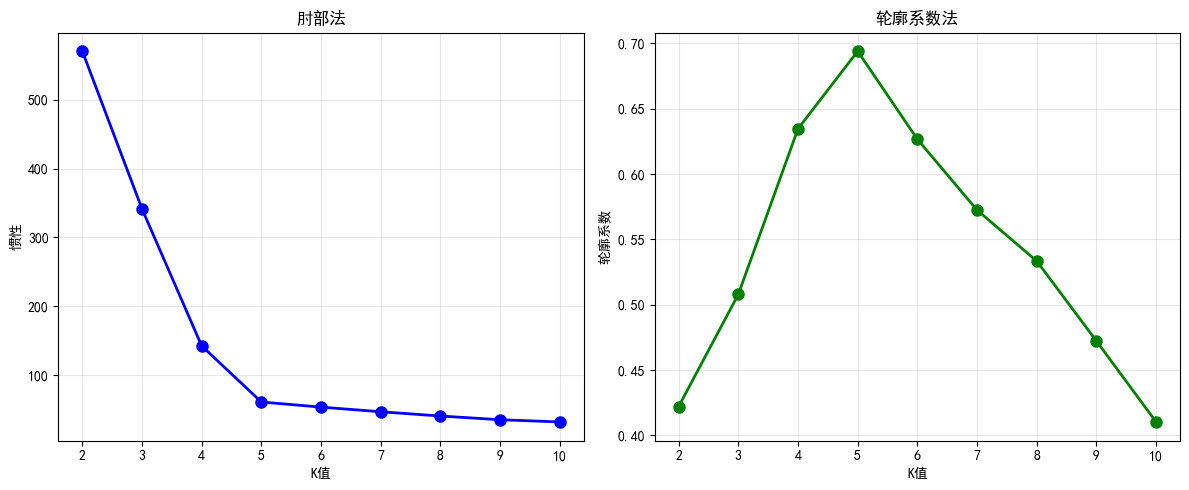

In [30]:
# 使用年收入和消费评分进行聚类
X_customer = customer_data[['annual_income', 'spending_score']].values

# 标准化
scaler = StandardScaler()
X_customer_scaled = scaler.fit_transform(X_customer)

# 确定K值
inertias_cust = []
sil_scores_cust = []
K_range_cust = range(2, 11)

for k in K_range_cust:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_customer_scaled)
    inertias_cust.append(km_temp.inertia_)
    sil_scores_cust.append(silhouette_score(X_customer_scaled, km_temp.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range_cust, inertias_cust, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K值')
plt.ylabel('惯性')
plt.title('肘部法')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(K_range_cust, sil_scores_cust, 'go-', linewidth=2, markersize=8)
plt.xlabel('K值')
plt.ylabel('轮廓系数')
plt.title('轮廓系数法')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



解读：
1. 左图：肘部法则 (Elbow Method)：曲线呈现明显的单调递减趋势。从 K=5 开始，下降速度明显变缓，曲线趋于平滑。
2. 右图：轮廓系数法 (Silhouette Score)：越接近 1 越好，在 K=5的地方值最大。

In [31]:
# 选择K=5进行聚类
optimal_k = 5
kmeans_customer = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_clusters = kmeans_customer.fit_predict(X_customer_scaled)

customer_data['cluster'] = customer_clusters

print(f"\n聚类结果 (K={optimal_k}):")
print("-" * 40)
print(f"各簇客户数: {np.bincount(customer_clusters)}")
print(f"轮廓系数: {silhouette_score(X_customer_scaled, customer_clusters):.4f}")


聚类结果 (K=5):
----------------------------------------
各簇客户数: [100  99 100 100 101]
轮廓系数: 0.6940


聚类完毕，画图看看客户分群的效果：


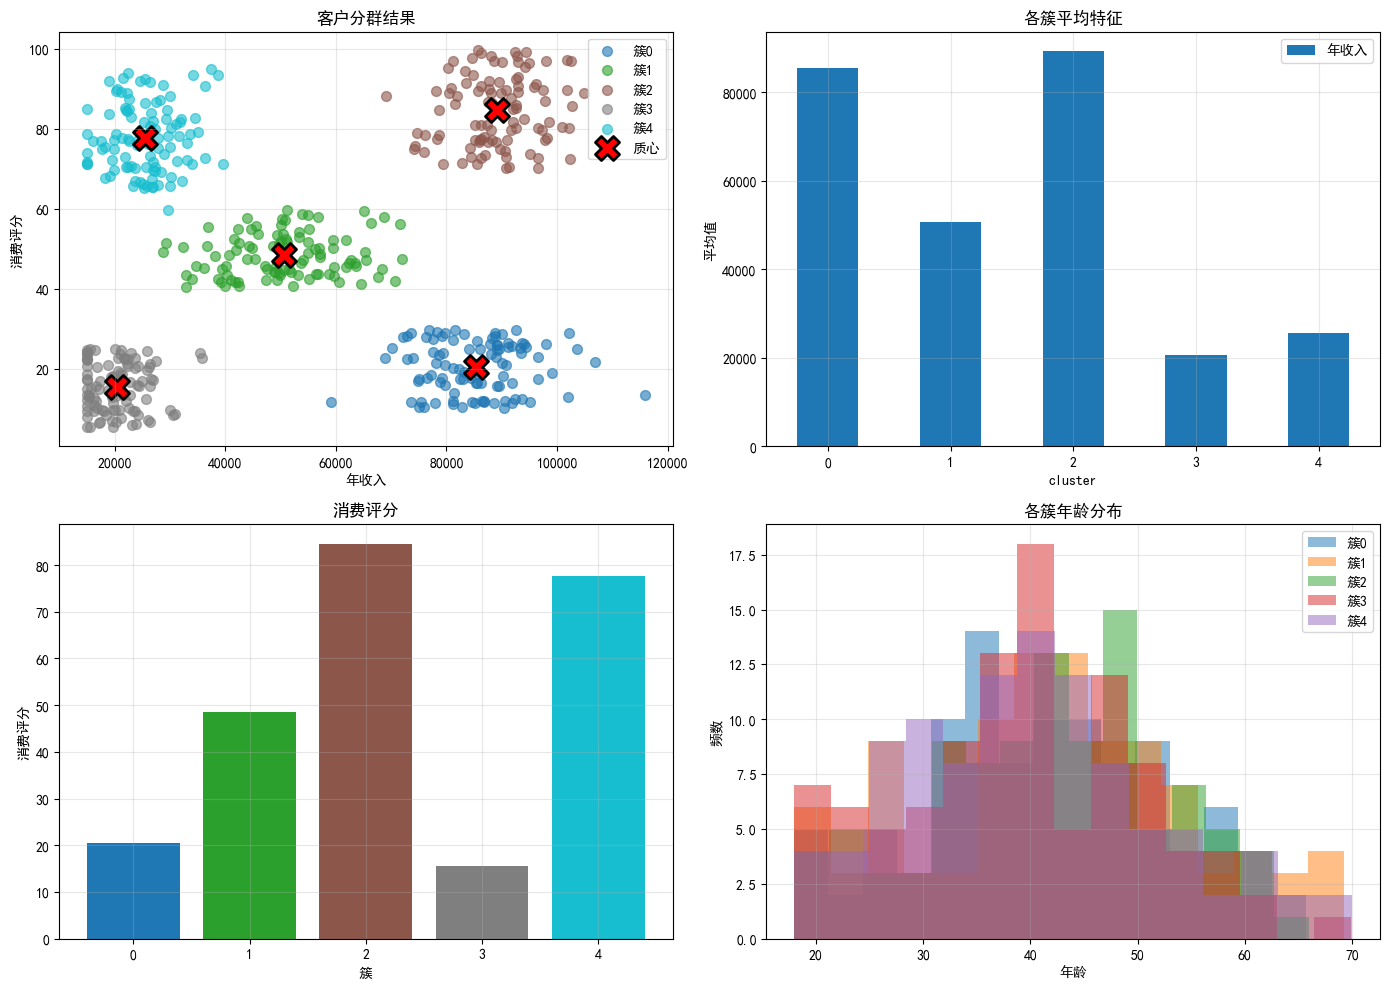


客户画像解读:

【簇0】客户数: 100
  年收入: 85295 ± 8779
  消费评分: 20.4 ± 6.2
  年龄: 41.4 ± 11.3
  购买频次: 10.0

【簇1】客户数: 99
  年收入: 50667 ± 10097
  消费评分: 48.4 ± 5.3
  年龄: 42.4 ± 12.5
  购买频次: 9.9

【簇2】客户数: 100
  年收入: 89169 ± 7265
  消费评分: 84.6 ± 8.6
  年龄: 42.0 ± 11.2
  购买频次: 10.0

【簇3】客户数: 100
  年收入: 20519 ± 4681
  消费评分: 15.5 ± 6.0
  年龄: 39.2 ± 11.3
  购买频次: 10.1

【簇4】客户数: 101
  年收入: 25586 ± 5704
  消费评分: 77.7 ± 8.5
  年龄: 40.2 ± 11.5
  购买频次: 10.1


In [37]:
# 可视化聚类结果
plt.figure(figsize=(14, 10))

# 散点图
plt.subplot(2, 2, 1)
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    cluster_data = X_customer[customer_clusters == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
               c=[colors[i]], label=f'簇{i}', alpha=0.6, s=50)

centroids_original = scaler.inverse_transform(kmeans_customer.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
           c='red', s=300, marker='X', edgecolors='k', linewidths=2, label='质心')
plt.xlabel('年收入')
plt.ylabel('消费评分')
plt.title('客户分群结果')
plt.legend()
plt.grid(True, alpha=0.3)

# 各簇特征分析
plt.subplot(2, 2, 2)
cluster_means = customer_data.groupby('cluster')[['annual_income']].mean()
cluster_means.plot(kind='bar', ax=plt.gca())
plt.title('各簇平均特征')
plt.ylabel('平均值')
plt.xticks(rotation=0)
plt.legend(['年收入'])
plt.grid(True, alpha=0.3)

# 购买频次
plt.subplot(2, 2, 3)
cluster_freq = customer_data.groupby('cluster')['spending_score'].mean()
plt.bar(range(optimal_k), cluster_freq.values, color=colors[:optimal_k])
plt.xlabel('簇')
plt.ylabel('消费评分')
plt.title('消费评分')
plt.xticks(range(optimal_k))
plt.grid(True, alpha=0.3)

# 年龄分布
plt.subplot(2, 2, 4)
for i in range(optimal_k):
    cluster_ages = customer_data[customer_data['cluster'] == i]['age']
    plt.hist(cluster_ages, alpha=0.5, label=f'簇{i}', bins=15)
plt.xlabel('年龄')
plt.ylabel('频数')
plt.title('各簇年龄分布')
plt.legend()
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

# 客户画像解读
print("\n客户画像解读:")
print("=" * 60)
for i in range(optimal_k):
    cluster_data = customer_data[customer_data['cluster'] == i]
    print(f"\n【簇{i}】客户数: {len(cluster_data)}")
    print(f"  年收入: {cluster_data['annual_income'].mean():.0f} ± {cluster_data['annual_income'].std():.0f}")
    print(f"  消费评分: {cluster_data['spending_score'].mean():.1f} ± {cluster_data['spending_score'].std():.1f}")
    print(f"  年龄: {cluster_data['age'].mean():.1f} ± {cluster_data['age'].std():.1f}")
    print(f"  购买频次: {cluster_data['purchase_frequency'].mean():.1f}")


---

## 八、聚类结果的业务解读

聚类不能只看轮廓系数，还得回到业务里解读每类的含义，如针对上面的报告，我们可以给出如下建议。

营销策略建议:

基于聚类结果的客户分群策略：

1. 【簇0】潜力客户（高收入+低消费）  
   特征: 有购买力但消费保守
   策略: 推送高端新品、会员权益、专属优惠，引导提升消费频次与客单价，挖掘消费潜力

2. 【簇1】大众主流客户 （中等收入+中等消费）
   特征: 收入、消费评分都处于中间水平，各项指标最均衡
   策略: 常规活动、爆款单品、日常促销即可维护，重点提升复购

3. 【簇2】高价值用户（高收入+高消费）
   特征: 购买力强、消费意愿足，是平台高利润来源
   策略: VIP 服务、限量款、高端套餐、专属售后，重点做留存与忠诚度维护

4. 【簇3】价格敏感客户（低收入+低消费）
   特征: 购买力有限
   策略: 主推低价刚需品、折扣、秒杀，团购优惠，积分奖励，避免高价产品推送

5. 【簇4】冲动消费客户（低收入+高消费）
   特征: 收入偏低，但消费评分很高
   策略: 打潮流单品、网红爆款、小额分期、趣味营销，刺激持续消费


---

## 九、小结

| 概念 | 说明 |
|------|------|
| **K-Means** | 基于质心的迭代聚类算法 |
| **惯性（Inertia）** | 簇内平方和，越小越好 |
| **轮廓系数** | [-1, 1]，越接近1聚类越好 |
| **肘部法则** | 找惯性下降变缓的K值 |

**K-Means使用流程**：
1. 数据标准化
2. 用肘部法则/轮廓系数确定K
3. 运行K-Means聚类
4. 分析各簇特征
5. 业务解读与应用

---

## 十、课后练习

1. 用K-Means对鸢尾花数据进行聚类，与真实标签对比
2. 尝试不同的K值，观察轮廓系数变化
3. 用K-Means进行图像颜色量化（把图片颜色减少到K种）
4. 思考：K-Means和分类算法有什么区别？

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score)
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, silhouette_samples

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

练习1：K-Means聚类鸢尾花数据

K-Means (K=3) 聚类结果:
  Adjusted Rand Score: 0.6201
  (范围[-1,1]，1表示完美匹配聚类)

聚类中心:
  聚类 0: [-0.05021989 -0.88337647  0.34773781  0.2815273 ]
  聚类 1: [-1.01457897  0.85326268 -1.30498732 -1.25489349]
  聚类 2: [1.13597027 0.08842168 0.99615451 1.01752612]


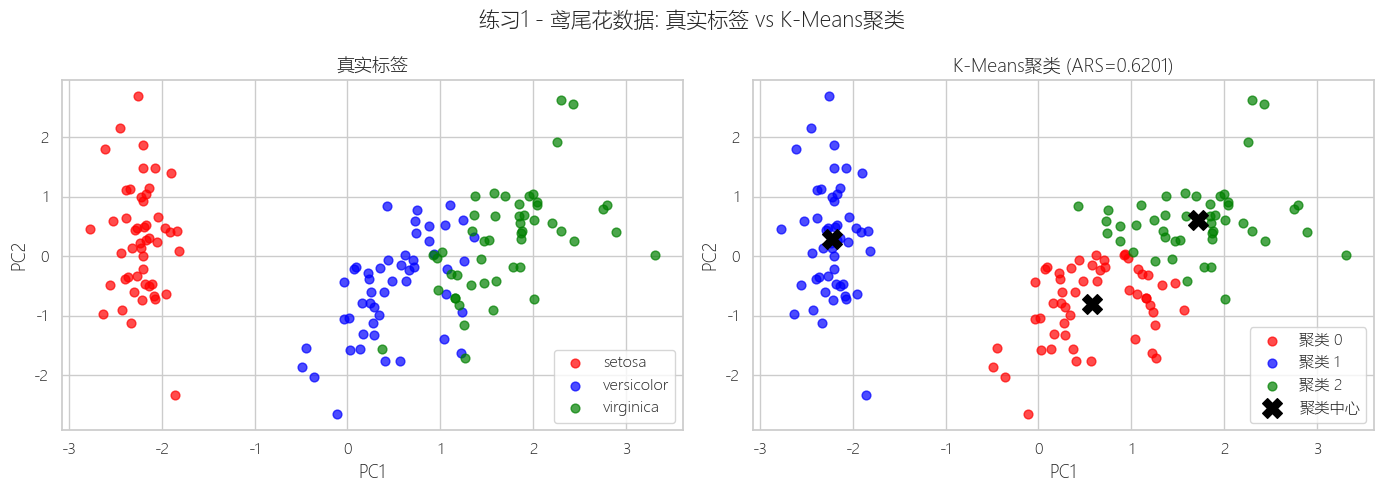

In [41]:
print("练习1：K-Means聚类鸢尾花数据")

iris = load_iris()
X = iris.data
y_true = iris.target

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means聚类（K=3）
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

# 计算Adjusted Rand Score
ars = adjusted_rand_score(y_true, y_pred)
print(f"\nK-Means (K=3) 聚类结果:")
print(f"  Adjusted Rand Score: {ars:.4f}")
print(f"  (范围[-1,1]，1表示完美匹配聚类)")
print(f"\n聚类中心:")
for i, center in enumerate(kmeans.cluster_centers_):
    print(f"  聚类 {i}: {center}")

# 可视化：用前两个主成分降维展示
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 真实标签
for i, color, name in zip([0, 1, 2], ['red', 'blue', 'green'], iris.target_names):
    axes[0].scatter(X_pca[y_true == i, 0], X_pca[y_true == i, 1],
                    c=color, label=name, alpha=0.7, s=40)
axes[0].set_title(f'真实标签', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# K-Means聚类结果
colors_cluster = ['red', 'blue', 'green']
for i in range(3):
    axes[1].scatter(X_pca[y_pred == i, 0], X_pca[y_pred == i, 1],
                    c=colors_cluster[i], label=f'聚类 {i}', alpha=0.7, s=40)
# 绘制聚类中心
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[1].scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X',
                s=200, label='聚类中心')
axes[1].set_title(f'K-Means聚类 (ARS={ars:.4f})', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('练习1 - 鸢尾花数据: 真实标签 vs K-Means聚类', fontsize=15)
plt.tight_layout()
plt.show()

练习2：不同K值的肘部法则与轮廓系数
  K=2: 惯性(Inertia)=222.36, 轮廓系数=0.5818
  K=3: 惯性(Inertia)=139.82, 轮廓系数=0.4599
  K=4: 惯性(Inertia)=114.09, 轮廓系数=0.3869
  K=5: 惯性(Inertia)=90.93, 轮廓系数=0.3459
  K=6: 惯性(Inertia)=81.54, 轮廓系数=0.3171
  K=7: 惯性(Inertia)=72.63, 轮廓系数=0.3202
  K=8: 惯性(Inertia)=62.54, 轮廓系数=0.3387

最佳K值（轮廓系数）: K=2, 轮廓系数=0.5818


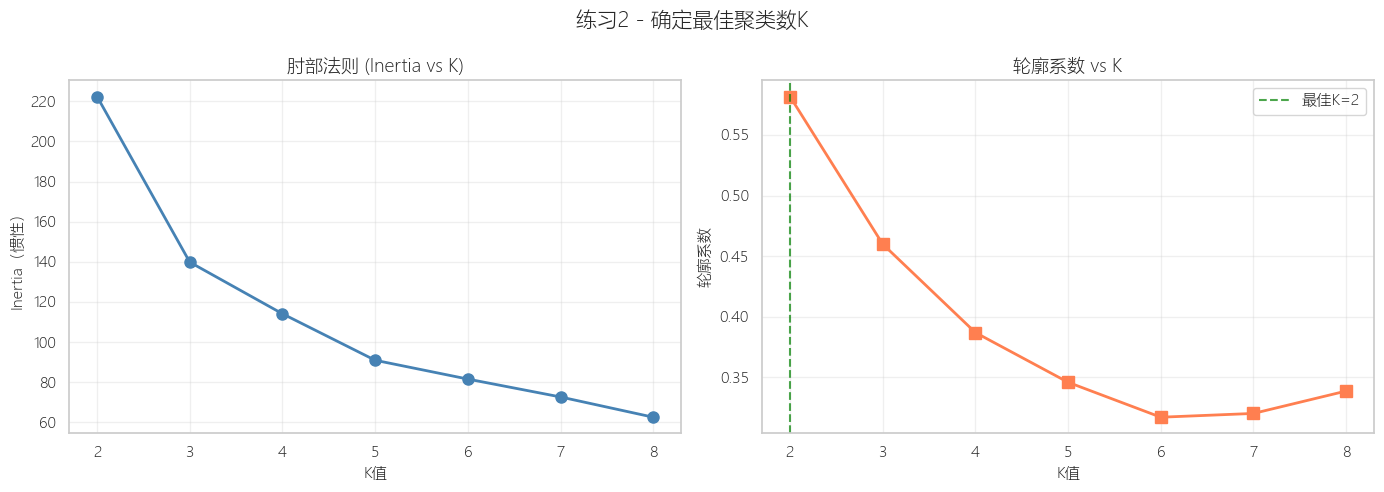

In [42]:
print("练习2：不同K值的肘部法则与轮廓系数")

K_range = range(2, 9)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)
    print(f"  K={k}: 惯性(Inertia)={km.inertia_:.2f}, 轮廓系数={sil:.4f}")

best_k_sil = list(K_range)[np.argmax(sil_scores)]
print(f"\n最佳K值（轮廓系数）: K={best_k_sil}, 轮廓系数={max(sil_scores):.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 肘部法则
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('肘部法则 (Inertia vs K)', fontsize=13)
axes[0].set_xlabel('K值', fontsize=11)
axes[0].set_ylabel('Inertia（惯性）', fontsize=11)
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# 轮廓系数
axes[1].plot(list(K_range), sil_scores, 's-', color='coral', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7,
                label=f'最佳K={best_k_sil}')
axes[1].set_title('轮廓系数 vs K', fontsize=13)
axes[1].set_xlabel('K值', fontsize=11)
axes[1].set_ylabel('轮廓系数', fontsize=11)
axes[1].set_xticks(list(K_range))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('练习2 - 确定最佳聚类数K', fontsize=15)
plt.tight_layout()
plt.show()

练习3：K-Means图像颜色量化
构造测试图片...
原始图片形状: (100, 100, 3), 颜色数: 8
  K=2: 量化后颜色数=2
  K=4: 量化后颜色数=4
  K=6: 量化后颜色数=6
  K=8: 量化后颜色数=8


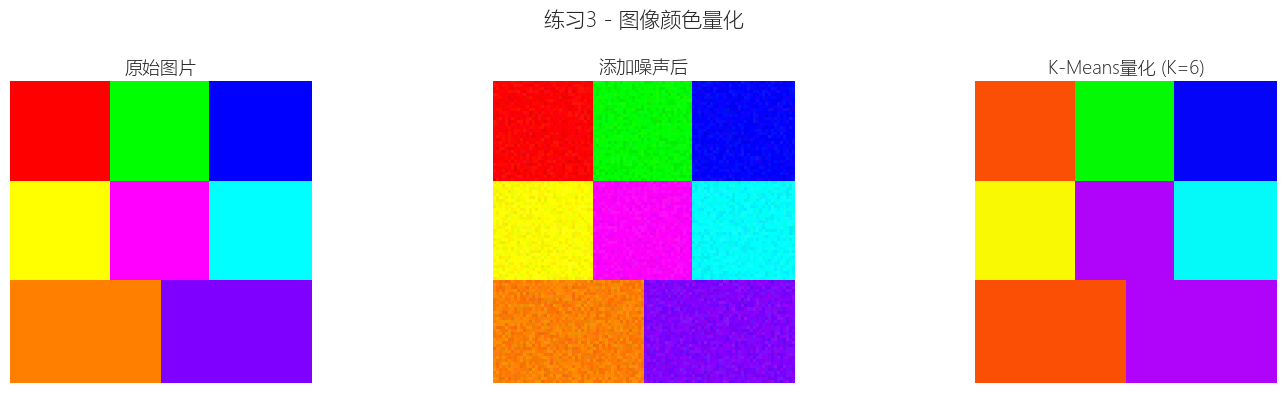

In [43]:
print("练习3：K-Means图像颜色量化")

# 构造一个彩色测试图片（渐变色块）
print("构造测试图片...")
img = np.zeros((100, 100, 3), dtype=np.uint8)
# 创建不同颜色的区域
img[:33, :33] = [255, 0, 0]       # 红色
img[:33, 33:66] = [0, 255, 0]     # 绿色
img[:33, 66:] = [0, 0, 255]       # 蓝色
img[33:66, :33] = [255, 255, 0]   # 黄色
img[33:66, 33:66] = [255, 0, 255] # 品红
img[33:66, 66:] = [0, 255, 255]   # 青色
img[66:, :50] = [255, 128, 0]     # 橙色
img[66:, 50:] = [128, 0, 255]     # 紫色
print(f"原始图片形状: {img.shape}, 颜色数: {len(np.unique(img.reshape(-1, 3), axis=0))}")

# 添加一些噪声
np.random.seed(42)
noise = np.random.randint(-20, 20, img.shape)
img_noisy = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)

# K-Means颜色量化
for n_colors in [2, 4, 6, 8]:
    img_flat = img_noisy.reshape(-1, 3).astype(float)
    kmeans_img = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    labels = kmeans_img.fit_predict(img_flat)
    img_quantized = kmeans_img.cluster_centers_[labels].astype(np.uint8).reshape(img_noisy.shape)

    unique_colors = len(np.unique(img_quantized.reshape(-1, 3), axis=0))
    print(f"  K={n_colors}: 量化后颜色数={unique_colors}")

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img)
axes[0].set_title('原始图片', fontsize=13)
axes[0].axis('off')

axes[1].imshow(img_noisy)
axes[1].set_title('添加噪声后', fontsize=13)
axes[1].axis('off')

# 用K=6量化
img_flat = img_noisy.reshape(-1, 3).astype(float)
km6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels6 = km6.fit_predict(img_flat)
img_q6 = km6.cluster_centers_[labels6].astype(np.uint8).reshape(img_noisy.shape)
axes[2].imshow(img_q6)
axes[2].set_title('K-Means量化 (K=6)', fontsize=13)
axes[2].axis('off')

plt.suptitle('练习3 - 图像颜色量化', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
K-Means和分类算法有什么区别？

A: 1. 有监督 vs 无监督：
      - 分类算法：有监督学习，需要标注好的标签数据（X, y）
      - K-Means：无监督学习，只需要特征数据X，不需要标签

   2. 学习目标不同：
      - 分类：学习从X到已知类别y的映射关系
      - K-Means：发现数据中的自然分组/结构，聚类标签是算法自动生成的

   3. 评估方式不同：
      - 分类：用准确率、F1、AUC等，需要有真实标签作为参照
      - K-Means：用轮廓系数、惯性等内部指标，不依赖外部标签

   4. 聚类标签的含义：
      - 分类：标签有明确含义（如"猫"、"狗"）
      - K-Means：聚类编号是任意的，聚类0和聚类1交换位置不影响结果

   5. 应用场景不同：
      - 分类：垃圾邮件检测、疾病诊断、情感分析
      - K-Means：客户分群、图像分割、异常检测、数据探索

   6. 模型输出的使用：
      - 分类：可直接用于预测新样本的类别
      - K-Means：可以将新样本分配到最近的聚类中心，但聚类本身的含义需要人工解读

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 56 篇：PCA 主成分分析 — 降维**
>
> 下篇学 PCA 主成分分析——把高维数据压缩到低维，同时保留主要信息，是数据可视化和特征压缩的利器。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*